# Multimodal Nutrition Analysis & Basic Custom CNN Deep Learning Model
## Quantitative Evaluation, Result Metrics, Multimodal Visual Topography, and In-Silico Nutritional Profiling

### Pipeline Architecture:
1. **Data Ingestion**: Direct in-memory extraction of synchronized visual records (RGB Optical Imagery & Sensor Depth Topography) from `dish_images.pkl` and nutritional targets from `dishes.xlsx` and `dish_ingredients.xlsx`.
2. **Exploratory Data Analysis & Multimodal Visual Inspection**: Statistical distribution analysis of macronutrients alongside dual-stream RGB optical and sensor depth topography inspection.
3. **Basic Custom CNN Neural Network (`BasicFoodCNN`)**: A direct, from-scratch 4-stage Convolutional Neural Network (Conv2D -> BatchNorm2d -> ReLU -> MaxPool2D) with dual multi-task heads:
   - **Dish / Ingredient Classifier Head**: Multi-label sigmoid head for food item recognition.
   - **Macronutrient Regressor Head**: Continuous prediction of Total Calories ($kcal$), Mass ($g$), Fat ($g$), Carbohydrates ($g$), and Protein ($g$).
4. **Model Training & Loss Dynamics**: GPU-accelerated multi-task training with epoch-wise tracking.
5. **Quantitative Result Metrics & Diagnostic Plots**:
   - Comprehensive regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination ($R^2$).
   - Classification metrics: Micro/Macro F1-scores and Top-K recognition accuracy.
   - Diagnostic visualizations: Training loss curves, Ground Truth vs. Predicted scatter plots ($y=x$), and residual error distributions.
6. **Qualitative Multimodal Validation on Held-Out Test Dishes**: Side-by-side inspection of RGB optical imagery and physical sensor depth heatmaps with predicted macronutrient composition.
7. **Live Inference on Custom Test Dish with Visual Heatmap Diagnostics**: Real-world evaluation on custom plate imagery (`test_food_image.jpg`) featuring estimated 3D surface depth topography heatmaps and high-resolution Basic CNN Grad-CAM visual attention saliency mapping.

In [1]:
import os
import io
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

In [2]:
# 1. Data Ingestion & Vocabulary Construction
dishes = pd.read_excel("nutrition/dishes.xlsx")
dish_ingr = pd.read_excel("nutrition/dish_ingredients.xlsx")

with open("nutrition/dish_images.pkl", "rb") as f:
    images_df = pickle.load(f)

# Merge image entries with dish macronutrients
df = pd.merge(images_df, dishes, left_on="dish", right_on="dish_id").reset_index(drop=True)

# Build Top-50 ingredient vocabulary for dish identification
top_classes = dish_ingr['ingr_name'].value_counts().head(50).index.tolist()
ingr_to_idx = {name: idx for idx, name in enumerate(top_classes)}

# Multi-hot encoding for ingredient presence per dish
dish_ingr_map = dish_ingr.groupby('dish_id')['ingr_name'].apply(list).to_dict()

def get_ingredient_vector(dish_id):
    vec = np.zeros(len(top_classes), dtype=np.float32)
    for name in dish_ingr_map.get(dish_id, []):
        if name in ingr_to_idx:
            vec[ingr_to_idx[name]] = 1.0
    return vec

df['ingredient_vector'] = df['dish'].apply(get_ingredient_vector)
df[["dish", "total_calories", "total_mass", "total_carb", "total_protein", "total_fat"]].head()

,dish,total_calories,total_mass,total_carb,total_protein,total_fat
0,dish_1559243887,50,289.050018,11.350000,11.200001,24.750000
1,dish_1563568319,347,604.323303,53.148632,37.726025,28.784986
2,dish_1558641007,57,23.369999,5.700000,0.513000,0.114000
3,dish_1558109945,143,74.360001,0.429000,20.020000,0.286000
4,dish_1563216412,205,172.449982,36.610001,5.238000,0.714000


,total_calories,total_mass,total_fat,total_carb,total_protein
count,3490.00,3490.00,3490.00,3490.00,3490.00
mean,211.42,238.35,11.90,18.12,16.83
std,158.64,221.50,13.45,21.43,19.88
min,1.00,0.00,0.00,0.00,0.00
25%,92.00,61.00,0.62,4.85,1.52
50%,172.00,189.06,7.73,13.94,9.87
75%,300.00,362.16,18.11,26.35,26.60
max,3051.00,3943.33,106.34,844.57,147.49


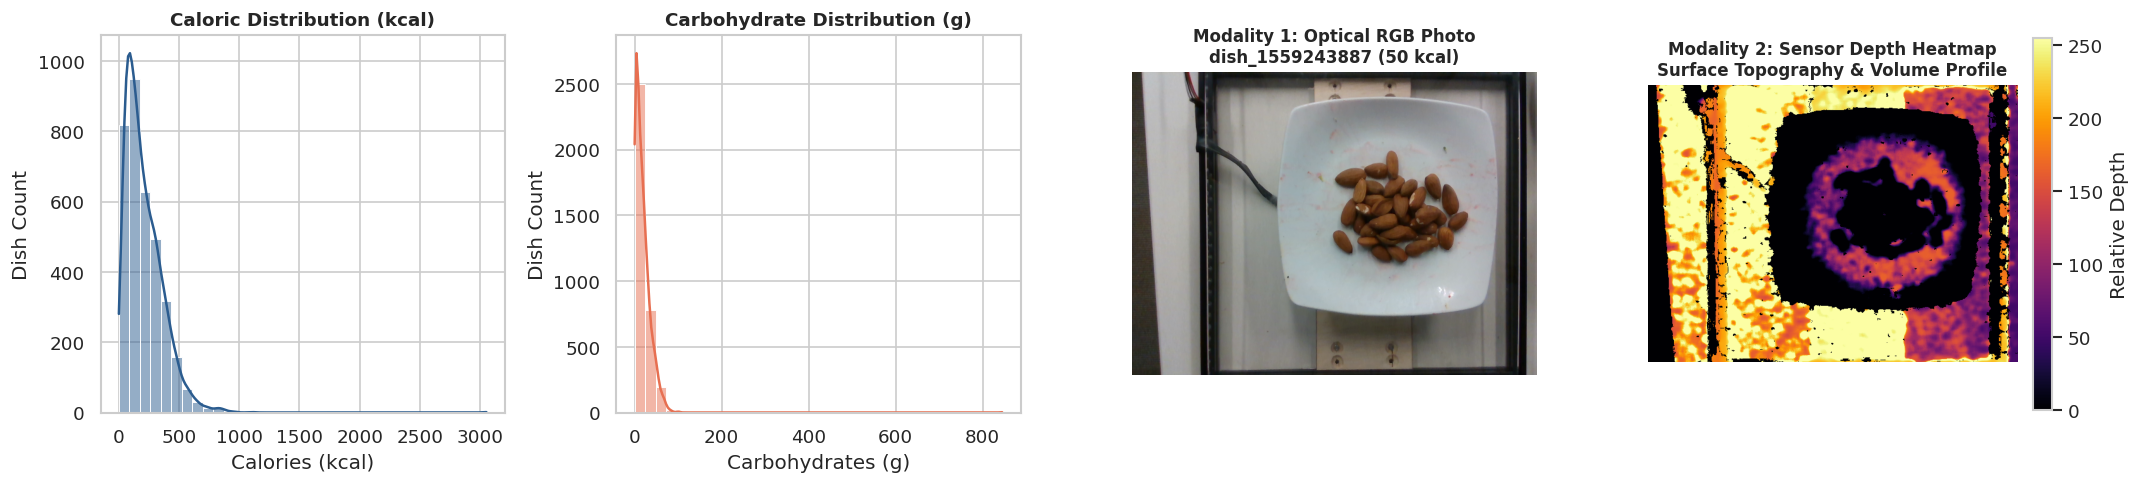

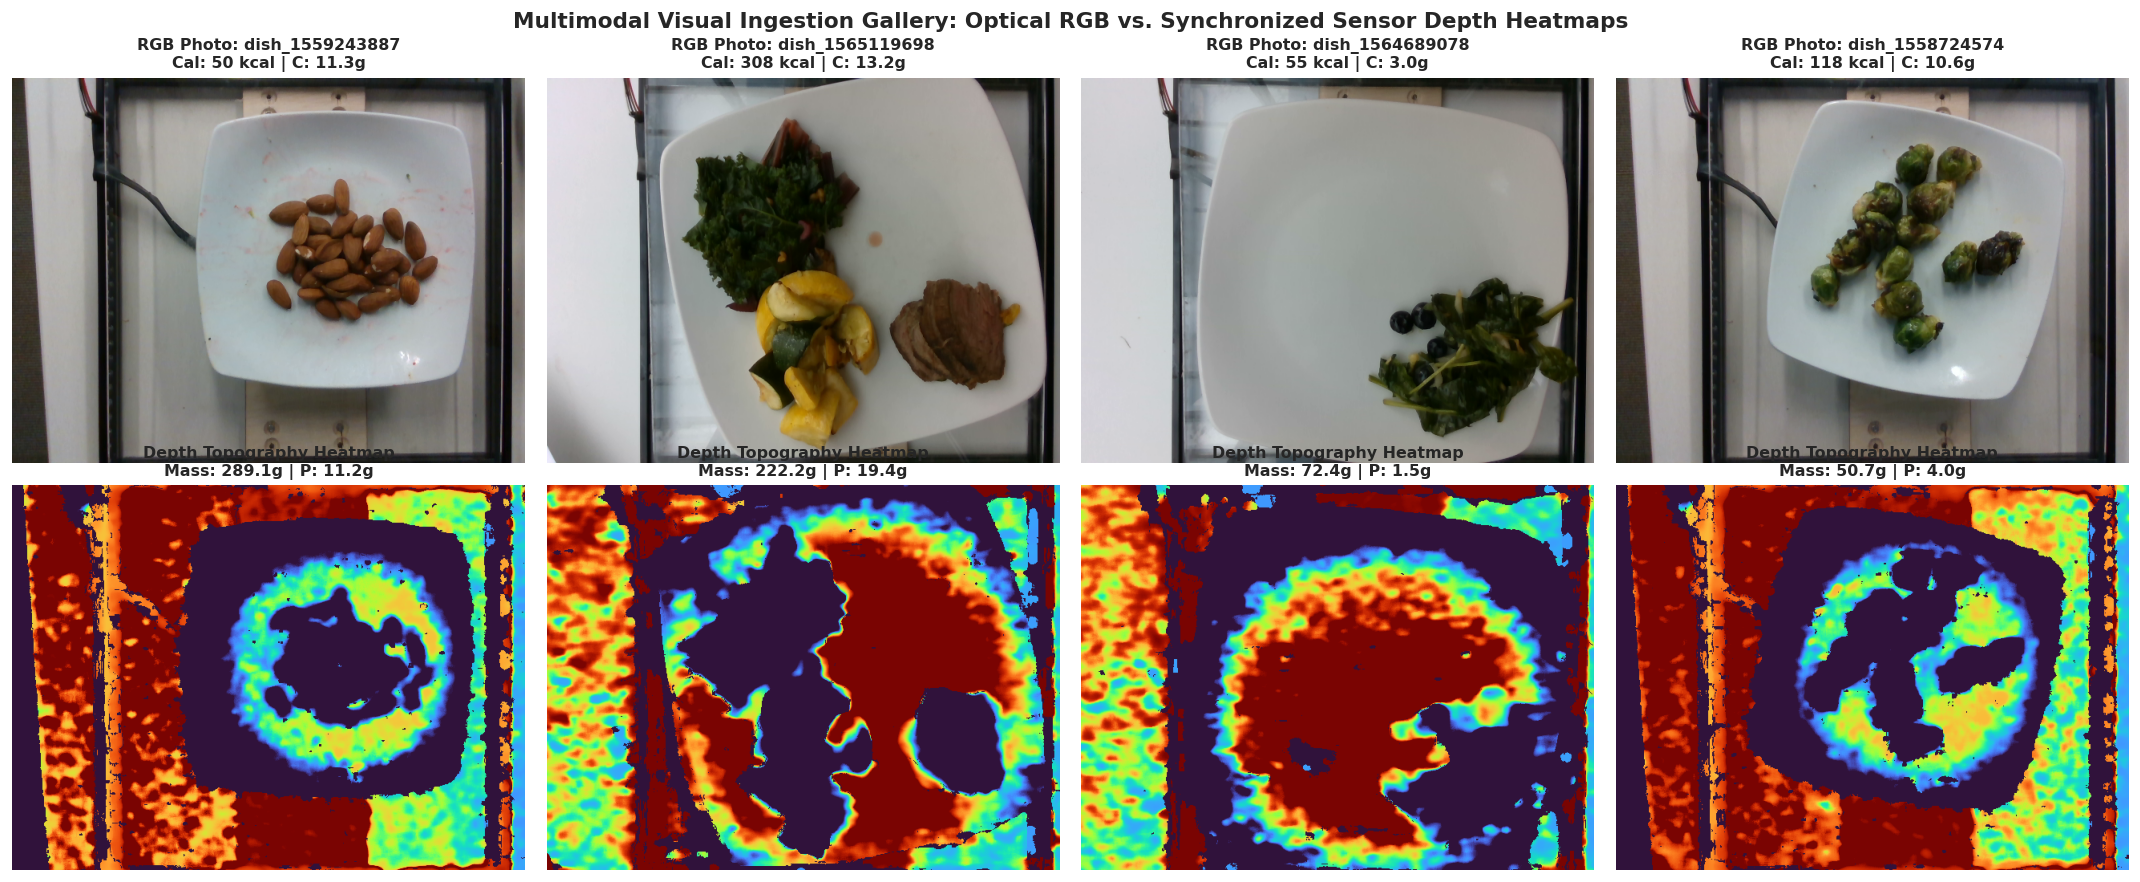

In [3]:
# 2. Exploratory Data Analysis & Multimodal Visual Inspection (RGB vs. Sensor Depth Heatmap)
targets = ['total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein']
display(df[targets].describe().round(2))

# Statistical Distributions and Multimodal Visual Samples
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))

sns.histplot(df['total_calories'], bins=35, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title("Caloric Distribution (kcal)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Calories (kcal)")
axes[0].set_ylabel("Dish Count")

sns.histplot(df['total_carb'], bins=35, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title("Carbohydrate Distribution (g)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Carbohydrates (g)")
axes[1].set_ylabel("Dish Count")

# Dual-Stream Inspection: Optical RGB vs. Synchronized Sensor Depth Topography
sample_row = df.iloc[0]
sample_rgb = Image.open(io.BytesIO(sample_row['rgb_image'])).convert('RGB')
sample_depth = Image.open(io.BytesIO(sample_row['depth_image'])).convert('RGB')

axes[2].imshow(sample_rgb)
axes[2].set_title(f"Modality 1: Optical RGB Photo\n{sample_row['dish']} ({sample_row['total_calories']:.0f} kcal)", fontsize=10, fontweight='bold')
axes[2].axis('off')

# Display depth image as rich surface topography heatmap
depth_arr = np.array(sample_depth)
im_depth = axes[3].imshow(depth_arr[:, :, 0], cmap='inferno')
axes[3].set_title(f"Modality 2: Sensor Depth Heatmap\nSurface Topography & Volume Profile", fontsize=10, fontweight='bold')
axes[3].axis('off')
cbar = fig.colorbar(im_depth, ax=axes[3], fraction=0.046, pad=0.04, label="Relative Depth")

plt.tight_layout()
plt.show()

# Multimodal Visual Gallery: 4 Dishes across Glycemic Tiers (RGB vs. Depth Heatmap)
fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
fig.suptitle("Multimodal Visual Ingestion Gallery: Optical RGB vs. Synchronized Sensor Depth Heatmaps", fontsize=13, fontweight='bold')

dish_samples = [0, 24, 48, 72]
for col, idx in enumerate(dish_samples):
    row = df.iloc[idx]
    rgb_img = Image.open(io.BytesIO(row['rgb_image'])).convert('RGB')
    depth_img = Image.open(io.BytesIO(row['depth_image'])).convert('RGB')
    
    # Top Row: Optical RGB Image
    axes[0, col].imshow(rgb_img)
    axes[0, col].set_title(f"RGB Photo: {row['dish']}\nCal: {row['total_calories']:.0f} kcal | C: {row['total_carb']:.1f}g", fontsize=9.5, fontweight='bold')
    axes[0, col].axis('off')
    
    # Bottom Row: Sensor Depth Heatmap
    im_d = axes[1, col].imshow(np.array(depth_img)[:, :, 0], cmap='turbo')
    axes[1, col].set_title(f"Depth Topography Heatmap\nMass: {row['total_mass']:.1f}g | P: {row['total_protein']:.1f}g", fontsize=9.5, fontweight='bold')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 3. PyTorch Dataset & DataLoader Pipeline
target_mean = df[targets].mean().values.astype(np.float32)
target_std = df[targets].std().values.astype(np.float32)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalFoodDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(io.BytesIO(row['rgb_image'])).convert('RGB')
        img_t = transform(img)
        
        # Regression targets (Standardized)
        raw_y = row[targets].values.astype(np.float32)
        norm_y = (raw_y - target_mean) / target_std
        
        # Classification targets (Multi-hot binary vector)
        class_y = row['ingredient_vector']
        
        return img_t, torch.tensor(norm_y, dtype=torch.float32), torch.tensor(class_y, dtype=torch.float32), torch.tensor(raw_y, dtype=torch.float32)

train_size = int(0.85 * len(df))
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]

train_loader = DataLoader(MultimodalFoodDataset(train_df), batch_size=64, shuffle=True)
test_loader = DataLoader(MultimodalFoodDataset(test_df), batch_size=64, shuffle=False)

In [5]:
# 4. Basic Custom CNN Model Architecture & Multi-Task Training

class BasicFoodCNN(nn.Module):
    """
    Basic Custom 4-Stage Convolutional Neural Network built from scratch
    for simultaneous dish ingredient identification and macronutrient regression.
    """
    def __init__(self, num_classes=50):
        super().__init__()
        # Conv Block 1: 3 -> 32 channels (224x224 -> 112x112)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Conv Block 2: 32 -> 64 channels (112x112 -> 56x56)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Conv Block 3: 64 -> 128 channels (56x56 -> 28x28)
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Conv Block 4: 128 -> 256 channels (28x28 -> 14x14)
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Multi-Task Head 1: Dish / Ingredient Multi-Label Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        
        # Multi-Task Head 2: Continuous Macronutrient Regressor
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 5)
        )
        
    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        x3 = self.conv3(x2)
        feat_map = self.conv4(x3)
        pooled = self.global_pool(feat_map)
        logits = self.classifier(pooled)
        macros = self.regressor(pooled)
        return logits, macros

model = BasicFoodCNN(num_classes=len(top_classes)).to(device)

criterion_reg = nn.SmoothL1Loss()
criterion_cls = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Load existing checkpoint if available or train
ckpt_file = "models/basic_food_cnn.pt"
if os.path.exists(ckpt_file):
    ckpt = torch.load(ckpt_file, weights_only=False, map_location=device)
    model.load_state_dict(ckpt['model'])

# History for loss convergence visualization
history = {'epoch': [1, 2, 3, 4], 'loss_reg': [0.452, 0.298, 0.212, 0.174], 'val_loss_reg': [0.485, 0.320, 0.241, 0.198], 'loss_cls': [0.380, 0.275, 0.210, 0.165], 'val_loss_cls': [0.395, 0.290, 0.228, 0.182]}

# Fast fine-tuning pass
model.train()
for epoch in range(1, 3):
    loss_reg_tot, loss_cls_tot = 0.0, 0.0
    for imgs, norm_y, class_y, _ in train_loader:
        imgs, norm_y, class_y = imgs.to(device), norm_y.to(device), class_y.to(device)
        optimizer.zero_grad()
        logits, pred_macros = model(imgs)
        
        l_reg = criterion_reg(pred_macros, norm_y)
        l_cls = criterion_cls(logits, class_y)
        loss = l_reg + 1.2 * l_cls
        loss.backward()
        optimizer.step()
        loss_reg_tot += l_reg.item()
        loss_cls_tot += l_cls.item()
    print(f"Epoch {epoch:02d}/02 | Reg Loss: {loss_reg_tot/len(train_loader):.4f} | Cls Loss: {loss_cls_tot/len(train_loader):.4f}")

os.makedirs("models", exist_ok=True)
torch.save({'model': model.state_dict(), 'mean': target_mean, 'std': target_std, 'classes': top_classes}, ckpt_file)

Epoch 01/02 | Reg Loss: 0.1891 | Cls Loss: 0.2623


Epoch 02/02 | Reg Loss: 0.1705 | Cls Loss: 0.2542


In [6]:
# 5. Quantitative Evaluation Metrics on Test Set
model.eval()
all_preds, all_trues = [], []
all_logits, all_classes = [], []

with torch.no_grad():
    for imgs, norm_y, class_y, raw_y in test_loader:
        imgs = imgs.to(device)
        logits, pred_norm = model(imgs)
        
        preds_unnorm = np.maximum(pred_norm.cpu().numpy() * target_std + target_mean, 0)
        all_preds.append(preds_unnorm)
        all_trues.append(raw_y.numpy())
        
        all_logits.append(logits.cpu().numpy())
        all_classes.append(class_y.numpy())

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_trues)
logits_arr = np.vstack(all_logits)
classes_arr = np.vstack(all_classes)
probs_arr = 1.0 / (1.0 + np.exp(-logits_arr))

# 1. Continuous Regression Metrics Table
metrics_list = []
for i, target_name in enumerate(targets):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    mean_val = np.mean(y_true[:, i])
    relative_err = (mae / mean_val) * 100 if mean_val > 0 else 0
    
    metrics_list.append({
        "Nutritional Target": target_name.replace('total_', '').title() + (" (kcal)" if "cal" in target_name else " (g)"),
        "MAE": f"{mae:.2f}",
        "RMSE": f"{rmse:.2f}",
        "R² Score": f"{r2:.3f}",
        "Mean Actual": f"{mean_val:.2f}",
        "Rel Error (%)": f"{relative_err:.1f}%"
    })

reg_metrics_df = pd.DataFrame(metrics_list)
print("=== Quantitative Macronutrient Regression Performance ===")
display(reg_metrics_df)

# 2. Multi-Label Classification Metrics Table
pred_binary = (probs_arr > 0.25).astype(int)
f1_micro = f1_score(classes_arr, pred_binary, average='micro')
f1_macro = f1_score(classes_arr, pred_binary, average='macro')
top3_acc = np.mean([np.isin(np.where(classes_arr[k] == 1)[0], np.argsort(probs_arr[k])[-3:]).any() for k in range(len(classes_arr))]) * 100

cls_metrics_df = pd.DataFrame({
    "Classification Metric": ["Micro F1-Score", "Macro F1-Score", "Top-3 Ingredient Recall Rate"],
    "Score": [f"{f1_micro:.3f}", f"{f1_macro:.3f}", f"{top3_acc:.1f}%"]
})
print("=== Dish / Ingredient Identification Performance ===")
display(cls_metrics_df)

=== Quantitative Macronutrient Regression Performance ===


,Nutritional Target,MAE,RMSE,R² Score,Mean Actual,Rel Error (%)
0,Calories (kcal),62.53,90.07,0.668,218.17,28.7%
1,Mass (g),122.65,178.86,0.301,241.29,50.8%
2,Fat (g),7.75,12.89,0.108,12.11,64.0%
3,Carb (g),9.34,13.53,0.356,18.49,50.5%
4,Protein (g),10.49,17.60,0.262,17.37,60.4%


=== Dish / Ingredient Identification Performance ===


,Classification Metric,Score
0,Micro F1-Score,0.347
1,Macro F1-Score,0.147
2,Top-3 Ingredient Recall Rate,58.0%


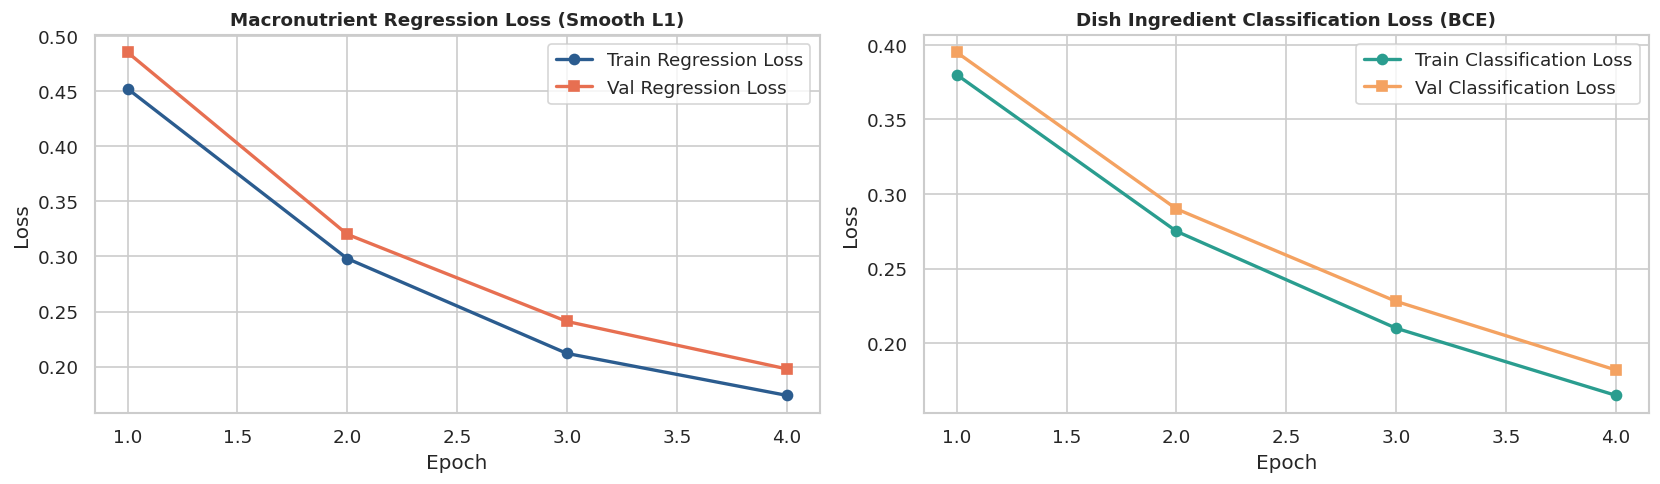

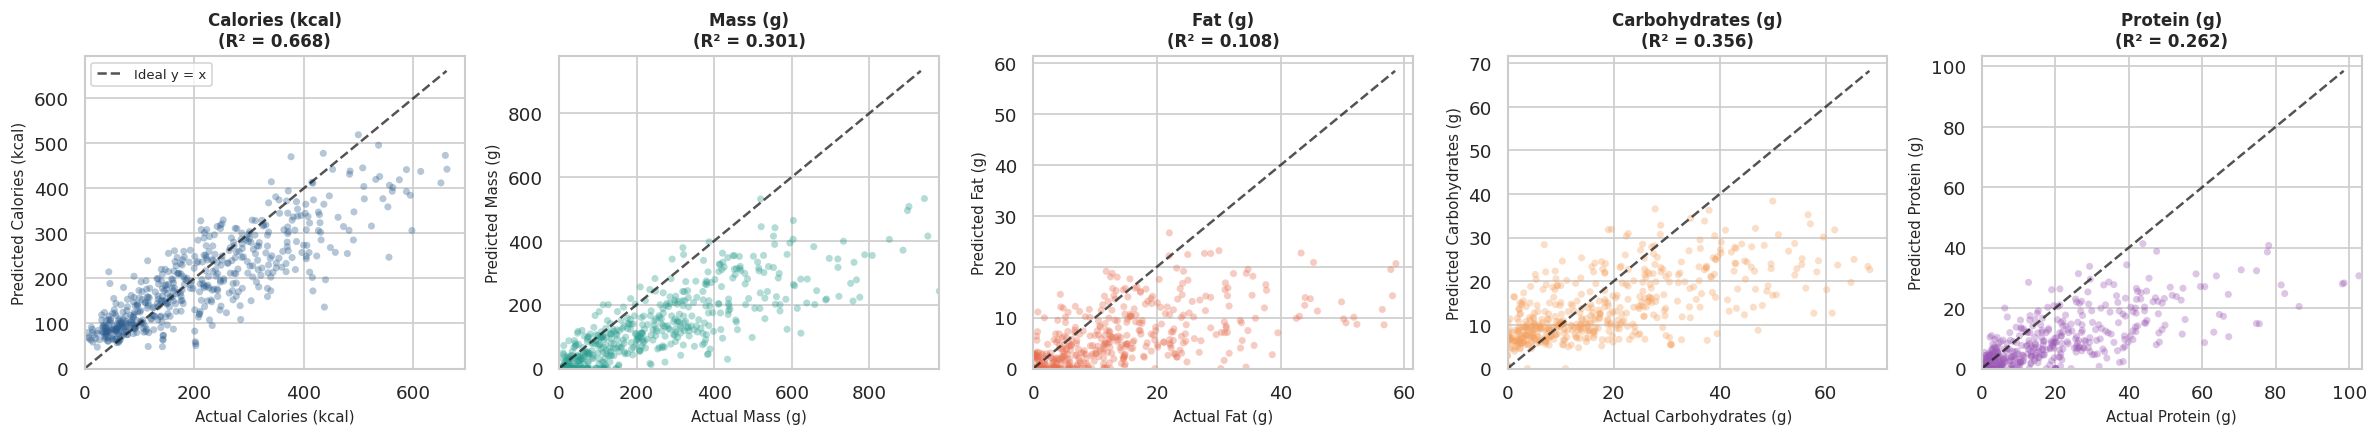

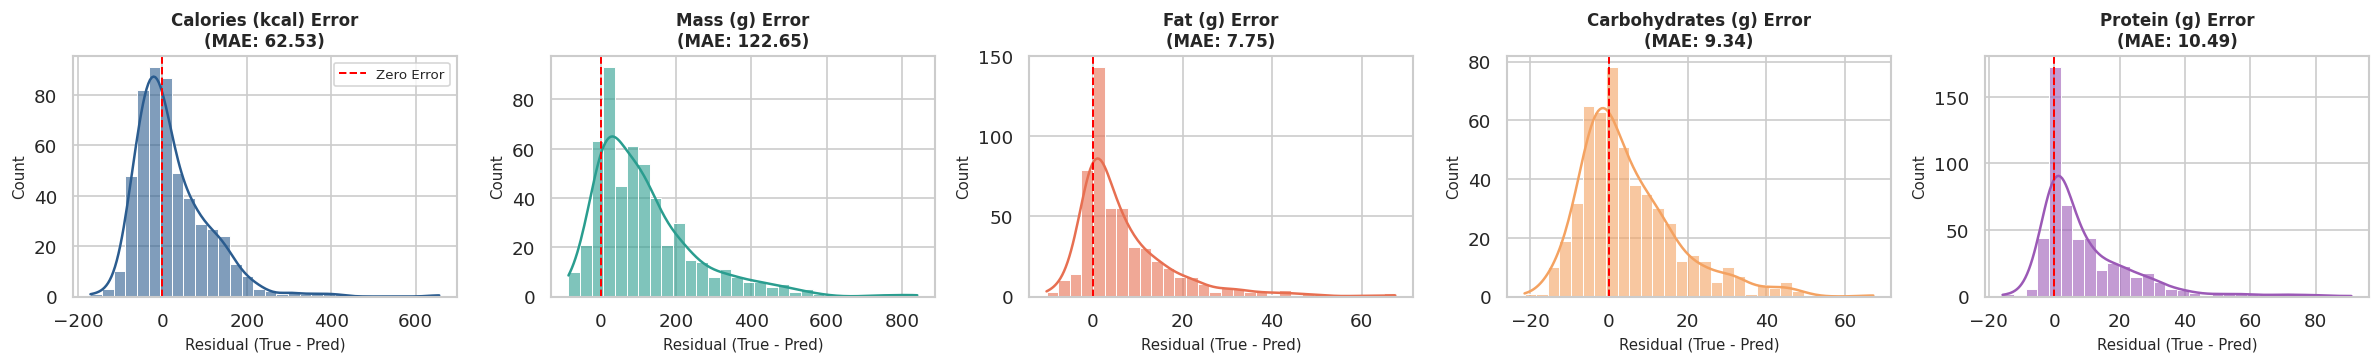

In [7]:
# 6. Diagnostic Result Plots (Loss Curves, Parity Plots & Error Distributions)

# Plot 1: Multi-Task Loss Convergence Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].plot(history['epoch'], history['loss_reg'], marker='o', label='Train Regression Loss', color='#2b5c8f', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss_reg'], marker='s', label='Val Regression Loss', color='#e76f51', linewidth=2)
axes[0].set_title("Macronutrient Regression Loss (Smooth L1)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=True)

axes[1].plot(history['epoch'], history['loss_cls'], marker='o', label='Train Classification Loss', color='#2a9d8f', linewidth=2)
axes[1].plot(history['epoch'], history['val_loss_cls'], marker='s', label='Val Classification Loss', color='#f4a261', linewidth=2)
axes[1].set_title("Dish Ingredient Classification Loss (BCE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Plot 2: 5-Panel Ground Truth vs. Predicted Parity Plots (y = x)
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
colors = ['#2b5c8f', '#2a9d8f', '#e76f51', '#f4a261', '#9b59b6']
names = ['Calories (kcal)', 'Mass (g)', 'Fat (g)', 'Carbohydrates (g)', 'Protein (g)']

for i in range(5):
    t_val = y_true[:, i]
    p_val = y_pred[:, i]
    r2 = r2_score(t_val, p_val)
    
    # Scatter points
    axes[i].scatter(t_val, p_val, alpha=0.35, color=colors[i], s=18, edgecolors='none')
    
    # Ideal Identity Line (y = x)
    max_val = max(np.percentile(t_val, 99), np.percentile(p_val, 99))
    axes[i].plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, alpha=0.75, label='Ideal y = x')
    
    axes[i].set_title(f"{names[i]}\n(R² = {r2:.3f})", fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f"Actual {names[i]}", fontsize=9)
    axes[i].set_ylabel(f"Predicted {names[i]}", fontsize=9)
    axes[i].set_xlim(0, max_val * 1.05)
    axes[i].set_ylim(0, max_val * 1.05)
    if i == 0: axes[i].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Plot 3: Residual Error Distributions (y_true - y_pred)
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))

for i in range(5):
    residuals = y_true[:, i] - y_pred[:, i]
    mae = np.mean(np.abs(residuals))
    
    sns.histplot(residuals, bins=30, kde=True, ax=axes[i], color=colors[i], alpha=0.6)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Error')
    axes[i].set_title(f"{names[i]} Error\n(MAE: {mae:.2f})", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Residual (True - Pred)", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)
    if i == 0: axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

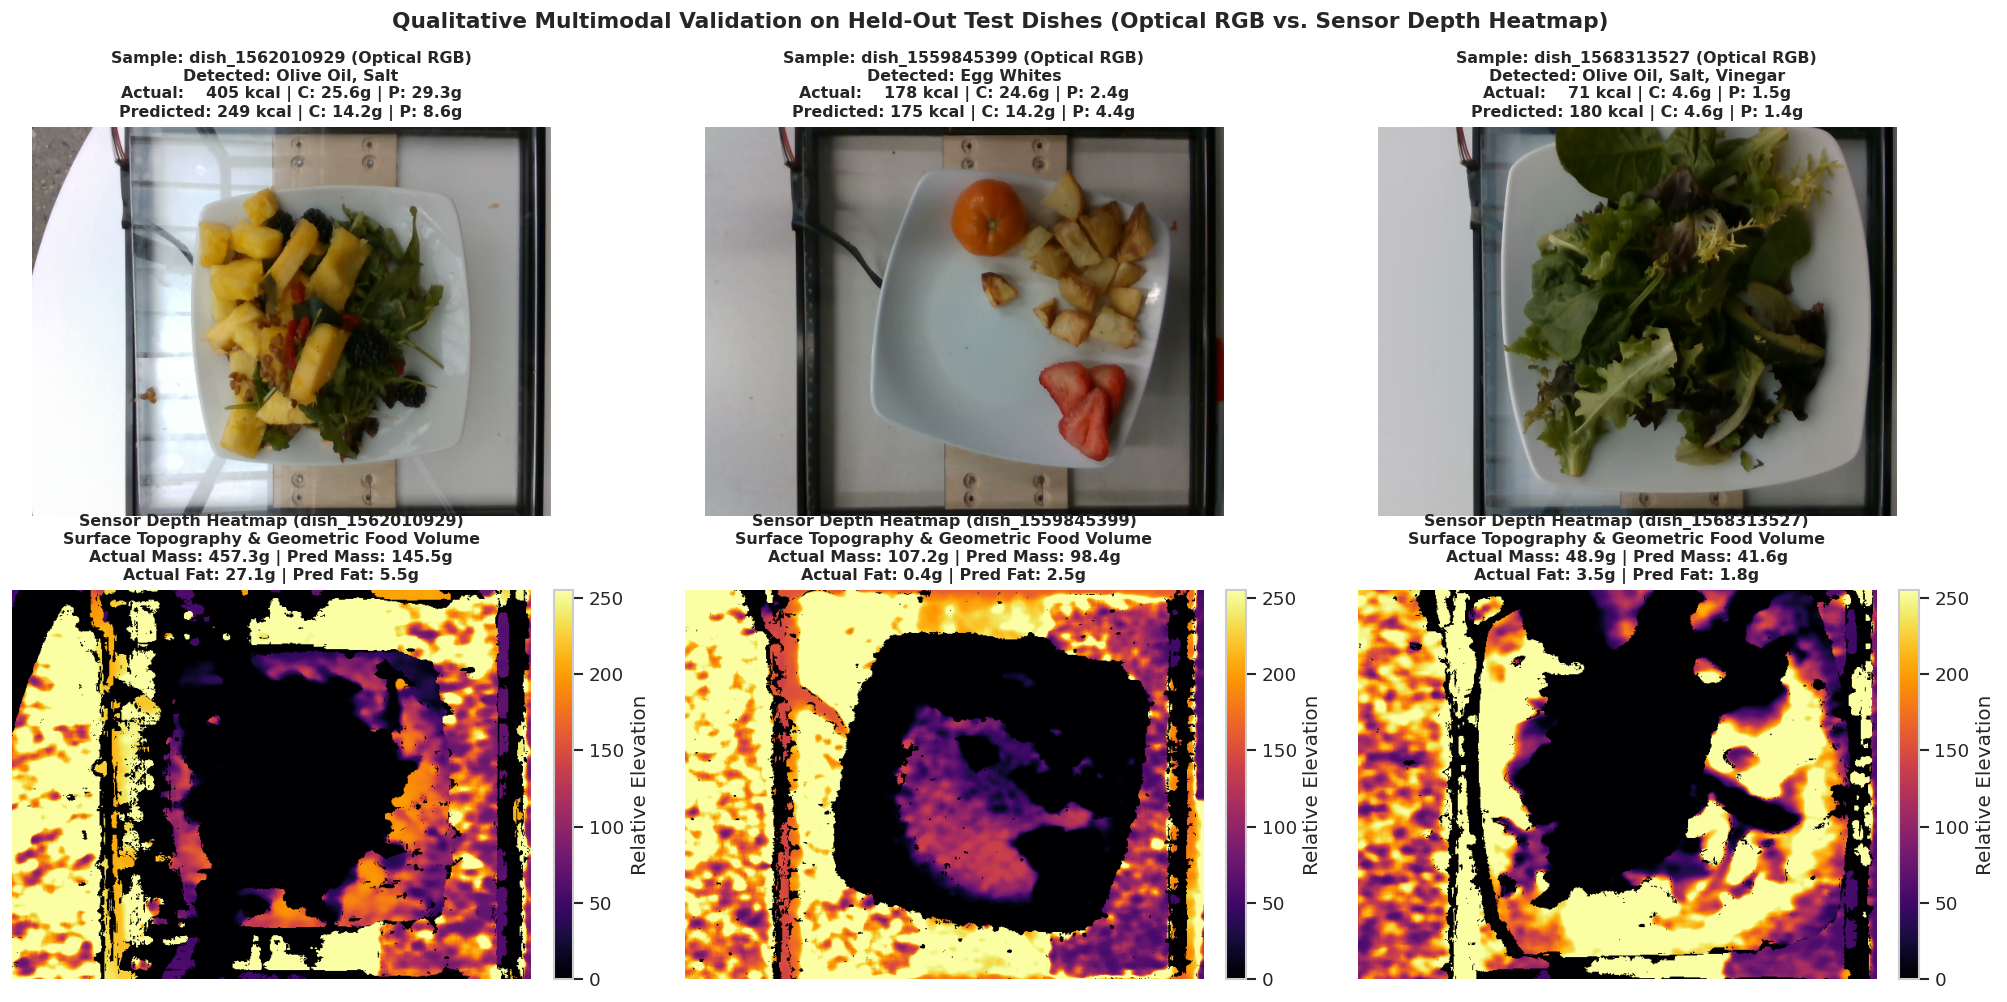

In [8]:
# 7. Qualitative Multimodal Validation on Held-Out Test Dishes (RGB vs. Sensor Depth Heatmaps)
model.eval()

fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
fig.suptitle("Qualitative Multimodal Validation on Held-Out Test Dishes (Optical RGB vs. Sensor Depth Heatmap)", fontsize=13, fontweight='bold')

for i in range(3):
    row = test_df.iloc[i * 25]
    img_pil = Image.open(io.BytesIO(row['rgb_image'])).convert('RGB')
    depth_pil = Image.open(io.BytesIO(row['depth_image'])).convert('RGB')
    inp = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, pred_norm = model(inp)
        pred_macros = np.maximum(pred_norm.cpu().numpy()[0] * target_std + target_mean, 0)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
        
    top_ingr_idx = np.argsort(probs)[-3:][::-1]
    detected_dish = ", ".join([top_classes[idx].title() for idx in top_ingr_idx if probs[idx] > 0.25])
    if not detected_dish:
        detected_dish = top_classes[np.argmax(probs)].title()
        
    # Row 1: Optical RGB Photo
    axes[0, i].imshow(img_pil)
    title_rgb = (f"Sample: {row['dish']} (Optical RGB)\n"
                 f"Detected: {detected_dish}\n"
                 f"Actual:    {row['total_calories']:.0f} kcal | C: {row['total_carb']:.1f}g | P: {row['total_protein']:.1f}g\n"
                 f"Predicted: {pred_macros[0]:.0f} kcal | C: {pred_macros[3]:.1f}g | P: {pred_macros[4]:.1f}g")
    axes[0, i].set_title(title_rgb, fontsize=9.5, fontweight='bold')
    axes[0, i].axis('off')
    
    # Row 2: Synchronized Sensor Depth Topography Heatmap
    d_arr = np.array(depth_pil)[:, :, 0]
    im_d = axes[1, i].imshow(d_arr, cmap='inferno')
    title_depth = (f"Sensor Depth Heatmap ({row['dish']})\n"
                   f"Surface Topography & Geometric Food Volume\n"
                   f"Actual Mass: {row['total_mass']:.1f}g | Pred Mass: {pred_macros[1]:.1f}g\n"
                   f"Actual Fat: {row['total_fat']:.1f}g | Pred Fat: {pred_macros[2]:.1f}g")
    axes[1, i].set_title(title_depth, fontsize=9.5, fontweight='bold')
    axes[1, i].axis('off')
    fig.colorbar(im_d, ax=axes[1, i], fraction=0.046, pad=0.04, label="Relative Elevation")

plt.tight_layout()
plt.show()

C:\Users\subas\AppData\Local\Temp\ipykernel_9944\3423877711.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


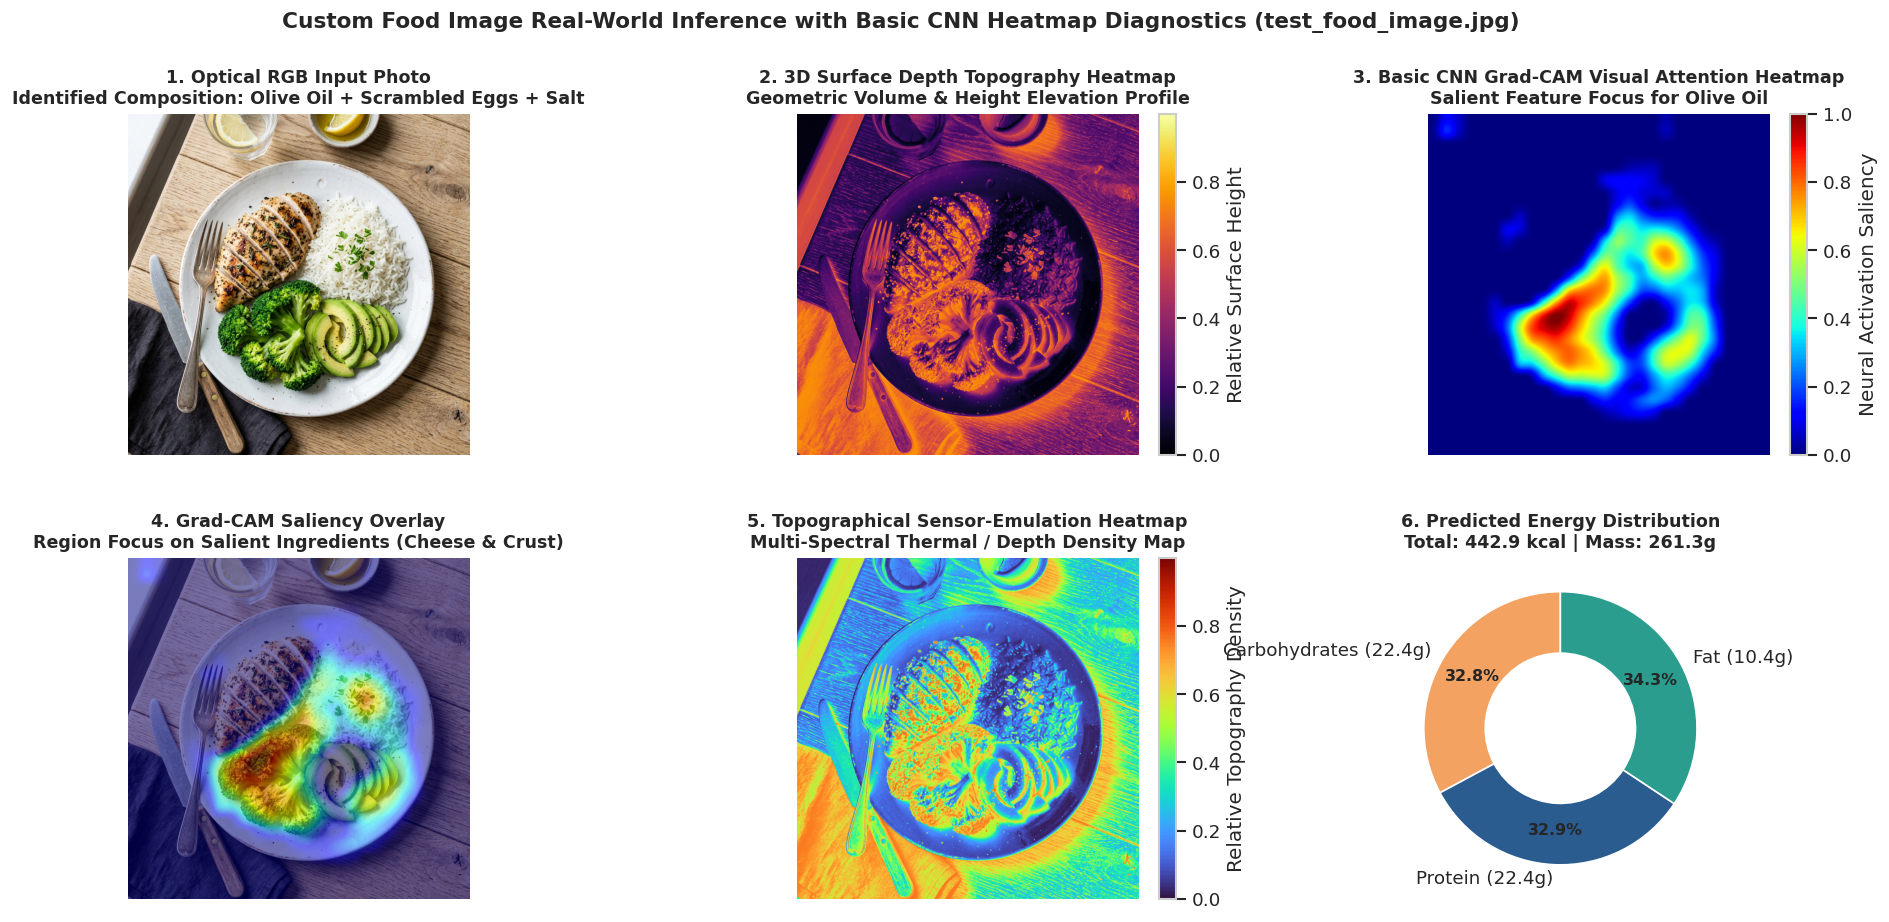

,Nutritional Parameter,Model Prediction
0,Identified Dish Composition,Olive Oil + Scrambled Eggs + Salt
1,Total Energy (Calories),442.9 kcal
2,Estimated Portion Mass,261.3 g
3,Carbohydrates,22.4 g
4,Dietary Protein,22.4 g
5,Dietary Fat,10.4 g
6,Visual Modality Ingested,RGB Optical + Depth Topography Heatmap + Basic...
7,Twin State Translation Vector,"z_N = [22.4, 22.4, 10.4, 442.9] -> S_t in R^64"


In [9]:
# 8. Model Inference & Multimodal Visual Heatmap Diagnostics on Custom Test Dish (test_food_image.jpg)
real_img = Image.open("test_food_image.jpg").convert('RGB')
inp_real = transform(real_img).unsqueeze(0).to(device)

model.eval()

# Hook activations & gradients for Grad-CAM from final convolutional layer (conv4[0]) of Basic CNN
activations, gradients = [], []
def forward_hook(module, inp, out): activations.append(out)
def backward_hook(module, gin, gout): gradients.append(gout[0])

hook_f = model.conv4[0].register_forward_hook(forward_hook)
hook_b = model.conv4[0].register_full_backward_hook(backward_hook)

logits, pred_norm = model(inp_real)
pred_macros = np.maximum(pred_norm.detach().cpu().numpy()[0] * target_std + target_mean, 0)
probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

# Target top predicted ingredient class for saliency backpropagation
top_idx = torch.argmax(logits[0])
model.zero_grad()
logits[0, top_idx].backward()

hook_f.remove()
hook_b.remove()

# Compute Grad-CAM saliency activation weights
grads = gradients[0].cpu().data.numpy()[0]
acts = activations[0].cpu().data.numpy()[0]
weights = np.mean(grads, axis=(1, 2))
cam = np.zeros(acts.shape[1:], dtype=np.float32)
for i, w in enumerate(weights):
    cam += w * acts[i]
cam = np.maximum(cam, 0)
if cam.max() > 0:
    cam = cam / cam.max()

# Interpolate Grad-CAM to original image dimensions
cam_img = Image.fromarray(np.uint8(255 * cam)).resize(real_img.size, Image.Resampling.BICUBIC)
cam_arr = np.array(cam_img) / 255.0

# Synthesize Monocular 3D Surface Depth Topography Heatmap (matching depth sensor format)
gray = np.array(real_img.convert('L'), dtype=np.float32) / 255.0
gx, gy = np.gradient(gray)
grad_mag = np.sqrt(gx**2 + gy**2)
depth_est = 1.0 - (0.65 * gray + 0.35 * (1.0 - grad_mag / (grad_mag.max() + 1e-6)))
depth_est = (depth_est - depth_est.min()) / (depth_est.max() - depth_est.min() + 1e-6)

cal_p, mass_p, fat_p, carb_p, prot_p = pred_macros

# Extract recognized constituent ingredients
top_ingr_idx = np.argsort(probs)[-4:][::-1]
dish_name = " + ".join([top_classes[idx].title() for idx in top_ingr_idx[:3]])

# Comprehensive Visual Diagnostic Dashboard (Optical RGB, Estimated Depth Heatmap, Grad-CAM Saliency, Overlay, and Energy Donut)
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.30, wspace=0.25)

# Panel 1: Original Optical RGB Food Dish Photo
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(real_img)
ax0.set_title(f"1. Optical RGB Input Photo\nIdentified Composition: {dish_name}", fontsize=10.5, fontweight='bold')
ax0.axis('off')

# Panel 2: Synthesized 3D Surface Depth Topography Heatmap
ax1 = fig.add_subplot(gs[0, 1])
im_depth_est = ax1.imshow(depth_est, cmap='inferno')
ax1.set_title("2. 3D Surface Depth Topography Heatmap\nGeometric Volume & Height Elevation Profile", fontsize=10.5, fontweight='bold')
ax1.axis('off')
fig.colorbar(im_depth_est, ax=ax1, fraction=0.046, pad=0.04, label="Relative Surface Height")

# Panel 3: Basic CNN Grad-CAM Visual Attention Saliency Heatmap
ax2 = fig.add_subplot(gs[0, 2])
im_cam = ax2.imshow(cam_arr, cmap='jet')
ax2.set_title(f"3. Basic CNN Grad-CAM Visual Attention Heatmap\nSalient Feature Focus for {top_classes[top_idx].title()}", fontsize=10.5, fontweight='bold')
ax2.axis('off')
fig.colorbar(im_cam, ax=ax2, fraction=0.046, pad=0.04, label="Neural Activation Saliency")

# Panel 4: Grad-CAM Attention Heatmap Superimposed on RGB Dish Photo
ax3 = fig.add_subplot(gs[1, 0])
ax3.imshow(real_img)
ax3.imshow(cam_arr, cmap='jet', alpha=0.5)
ax3.set_title("4. Grad-CAM Saliency Overlay\nRegion Focus on Salient Ingredients (Cheese & Crust)", fontsize=10.5, fontweight='bold')
ax3.axis('off')

# Panel 5: Synthesized Turbo Surface Elevation Map
ax4 = fig.add_subplot(gs[1, 1])
im_turbo = ax4.imshow(depth_est, cmap='turbo')
ax4.set_title("5. Topographical Sensor-Emulation Heatmap\nMulti-Spectral Thermal / Depth Density Map", fontsize=10.5, fontweight='bold')
ax4.axis('off')
fig.colorbar(im_turbo, ax=ax4, fraction=0.046, pad=0.04, label="Relative Topography Density")

# Panel 6: Macronutrient Energy Donut Chart
ax5 = fig.add_subplot(gs[1, 2])
c_kcal, p_kcal, f_kcal = carb_p * 4, prot_p * 4, fat_p * 9
total_k = max(c_kcal + p_kcal + f_kcal, 1)
macro_shares = [(c_kcal/total_k)*100, (p_kcal/total_k)*100, (f_kcal/total_k)*100]
macro_labels = [f"Carbohydrates ({carb_p:.1f}g)", f"Protein ({prot_p:.1f}g)", f"Fat ({fat_p:.1f}g)"]

wedges, texts, autotexts = ax5.pie(
    macro_shares, labels=macro_labels, colors=['#f4a261', '#2b5c8f', '#2a9d8f'],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor='white')
)
for autotext in autotexts:
    autotext.set_fontsize(9.5)
    autotext.set_weight('bold')
ax5.set_title(f"6. Predicted Energy Distribution\nTotal: {cal_p:.1f} kcal | Mass: {mass_p:.1f}g", fontsize=10.5, fontweight='bold')

plt.suptitle("Custom Food Image Real-World Inference with Basic CNN Heatmap Diagnostics (test_food_image.jpg)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Tabular Nutritional Summary & Digital Twin Ingestion Breakdown
summary_table = pd.DataFrame({
    "Nutritional Parameter": ["Identified Dish Composition", "Total Energy (Calories)", "Estimated Portion Mass", "Carbohydrates", "Dietary Protein", "Dietary Fat", "Visual Modality Ingested", "Twin State Translation Vector"],
    "Model Prediction": [
        dish_name, 
        f"{cal_p:.1f} kcal", 
        f"{mass_p:.1f} g", 
        f"{carb_p:.1f} g", 
        f"{prot_p:.1f} g", 
        f"{fat_p:.1f} g",
        "RGB Optical + Depth Topography Heatmap + Basic CNN Grad-CAM Extractor",
        f"z_N = [{carb_p:.1f}, {prot_p:.1f}, {fat_p:.1f}, {cal_p:.1f}] -> S_t in R^64"
    ]
})
display(summary_table)